# **9th Institute of Space Sciences Summer School** 
## Multimessenger Astrophysics

### *Hands-on Fermi data analysis*

### **Installation**

You will need

-Miniconda (regular conda is also an option)
https://www.anaconda.com/docs/getting-started/miniconda/install/overview

-Fermipy
https://fermipy.readthedocs.io/en/latest/install.html

-Jupyter Notebook
https://jupyter.org/install

In any case, if someone has Windows, WSL is reccommended (installation at https://learn.microsoft.com/en-us/windows/wsl/install ) as a virtual machine.


*Disclaimer*:
The following tutorial will be a simplified course on Fermi-LAT data analysis. For more details and examples, please see the [fermipy docs](https://fermipy.readthedocs.io/en/latest/tutorials.html). You can also find useful information at the [Fermi Science Support Center](https://fermi.gsfc.nasa.gov/ssc/), or a more comprehensive summary in the following document [github](https://github.com/marti-devesa/Methods_Computational_Physics-LAB).

### **Data access**

In this tutorial we will learn how to handle and analyse data from the Large Area Telescope, the main instrument on board the Fermi satellite. Its principal scientific objective is to conduct a long gamma-ray survey of celestial sources in the so-called high-energy regime (0.1 - 100 GeV), although it can detect individual photons up to 1 TeV. 

The Fermi-LAT scans the whole sky every ~3h in survey mode, and data is generaly publicly available less than 24h after its acquisition. To access the data, you can go to the [LAT Data Server](https://fermi.gsfc.nasa.gov/cgi-bin/ssc/LAT/LATDataQuery.cgi).

This will return two different file types:

- The photon file(s): a list with recorded events from that region of the sky

- The spacecraft information: the position of Fermi at a given time. 

The analysis is done through a maximum-likelihood-based approach (see [Mattox et al. 1996](https://articles.adsabs.harvard.edu/pdf/1996ApJ...461..396M) for a comprehensive description). That means that we will use spatial templates and source lists to model the background, and we will test the presence of additional sources on top of them. 

The standard analysis software are the [Fermitools](https://github.com/fermi-lat/ScienceTools/wiki/Quickstart-Guide) (terminal based), wich have a python wrapper known as Fermipy for easy integration into scripts. This is what will use today.

*Data for the tutorial*: here

Source: RS Oph

RA: 267.555°

Dec: -6.70791°

Time interval: August 8 to 18 of 2021


### **Caveats to take into account**

#### 1) We are count-limited

#### 2) The point-spread function is heavily dependent on energy

#### 3) An analysis focuses on the accumulated events for a region, not on telescope pointings


### **What will we do today?**

#### 1) Learn how to prepare the analysis

#### 2) Do a standard likelihood analysis

#### 3) Localize the source, produce the spectrum and a light curve



### **Before the analysis: The configuration file**

Fermi-LAT analysis with fermipy starts with the preparation of the configuration file. This contains the generic configuration of the source, data, the region of interest (ROI), and background model.

In [1]:
! cat config.yaml

data:
  evfile : PH00.fits
  scfile : SC00.fits

binning:
  roiwidth   : 20.0
  binsz      : 0.1
  binsperdec : 8
  coordsys : GAL

selection :
  emin : 100
  emax : 500000
  zmax : 90
  evclass : 128
  evtype  : 3
  filter  : 'DATA_QUAL>0 && LAT_CONFIG==1'
  ra :  267.555
  dec :  -6.70791
  tmin : 650073605
  tmax : 651801605

gtlike:
  edisp : True
  irfs : 'P8R3_SOURCE_V3'
  edisp_disable : ['isodiff']
  edisp_bins : -2

model:
  src_roiwidth : 25.0
  galdiff  : 'gll_iem_v07.fits'
  isodiff  : 'iso_P8R3_SOURCE_V3_v1.txt'
  catalogs : ['4FGL']


*Note 1*: Here we have little data and we have single photon file. You could pass a .txt list of them instead 

*Note 2*: Times are provided in mission ellapsed time (MET). You might fine useful the conversion tool https://heasarc.gsfc.nasa.gov/cgi-bin/Tools/xTime/xTime.pl


### **Quick start: the setup**


In [1]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter

gta = GTAnalysis('config.yaml')
gta.setup()

/home/willde/anaconda3/envs/fermi/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-02 15:19:36 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.2.2 
ScienceTools version 2.2.0
2026-07-02 15:19:37 INFO    GTAnalysis.setup(): Running setup.
2026-07-02 15:19:37 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2026-07-02 15:19:37 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2026-07-02 15:19:37 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2026-07-02 15:19:39 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 59434.000000 from DATE-OBS.
Set MJD-END to 59444.000000 from DATE-END'. [astropy.wcs.wcs]
2026-07-02 15:19:39 INFO    GTBinnedAnalysis._

Drm_Cache::update Measured counts < 0 4FGL J1709.9-0900 29 -1.64902e-14 2.54613e-14
0.0611976 0.127678 0.222609 0.330284 0.429159 0.488435 0.487936 0.433237 0.342954 0.240728 0.148421 0.0808728 0.0390984 0.0169177 0.00660674 0.00237046 0.000764035 0.00022167 5.79327e-05 1.37618e-05 3.00414e-06 5.86501e-07 1.01672e-07 1.58347e-08 2.22533e-09 2.81117e-10 3.20566e-11 3.30343e-12 3.06492e-13 2.54613e-14 


2026-07-02 15:20:10 INFO    GTAnalysis.setup(): Initializing source properties
2026-07-02 15:20:17 INFO    GTAnalysis.setup(): Finished setup.


We can print the source list (all loaded from the background now) to see if we are in the appropriate region

In [2]:
gta.print_roi()

2026-07-02 15:20:17 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1745.4-0753   PointSource    PowerLaw          1.671       nan         9.6
4FGL J1748.5-0854   PointSource    PowerLaw          2.233       nan         2.0
4FGL J1744.2-0353   PointSource    PowerLaw          3.191       nan         5.4
4FGL J1747.8-0316   PointSource    PowerLaw          3.488       nan         1.1
4FGL J1752.6-1010   PointSource    PowerLaw          3.520       nan         6.1
4FGL J1749.8-0303   PointSource    LogParabola       3.657       nan        11.7
4FGL J1735.3-0717   PointSource    LogParabola       3.732       nan         9.4
4FGL J1805.8-0803   PointSource    PowerLaw          4.095       nan         8.8
4FGL J1800.1-0323   PointSource    PowerLaw          4.134       nan         7.8
4FGL J1804.4-0852   PointSource    PowerLaw          4.1

As you can see, there is no TS assigned to the sources. This is because we have not computed the likelihood nor performed any fit.

So let's start with the analysis. The first step should always be to optimize the ROI. This can be done with the optimization function, which fits the 5 source expected to have the largest number of counts, and then the rest of sources individually.

In [19]:
# The optimization process takes some time, 
# so for simplicity we will just load an optimized state of the ROI
# This can be done and save as

#gta.optimize()
#gta.write_roi('opt')

# And loaded like
gta.load_roi('opt')

2026-07-02 15:41:02 INFO    GTAnalysis.load_roi(): Loading ROI file: /home/willde/Documents/Teaching/ICE_school/opt.npy
2026-07-02 15:41:03 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2026-07-02 15:41:31 INFO    GTAnalysis.load_roi(): Finished Loading ROI


The first optimization basicaly adapts the catalogue values to the specific ROI and time interval. **This is not a successful fit, only a preliminary step**.

In [20]:
# And we print again to see the see the first estimate on the TS for each source
gta.print_roi()

2026-07-02 15:41:31 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1745.4-0753   PointSource    PowerLaw          1.671    254.16       547.8
4FGL J1748.5-0854   PointSource    PowerLaw          2.233     -0.00         0.0
4FGL J1744.2-0353   PointSource    PowerLaw          3.191      6.23        49.4
4FGL J1747.8-0316   PointSource    PowerLaw          3.488      0.00         0.7
4FGL J1752.6-1010   PointSource    PowerLaw          3.520     -0.00         0.0
4FGL J1749.8-0303   PointSource    LogParabola       3.657     22.24        97.9
4FGL J1735.3-0717   PointSource    LogParabola       3.732     -0.00         0.0
4FGL J1805.8-0803   PointSource    PowerLaw          4.095     -0.00         0.0
4FGL J1800.1-0323   PointSource    PowerLaw          4.134     -0.00         0.0
4FGL J1804.4-0852   PointSource    PowerLaw          4.1

### **Standard analysis**

We can now proceed with a standard fit. In this example, we free the normalization of all sources within parameters within 7 degrees and all parameters for the sources detected above 5 sigma.

In [21]:
gta.free_sources(distance=10, pars='norm')
gta.free_sources(minmax_ts=[25,None])

gta.fit()

2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1745.4-0753     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1748.5-0854     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1744.2-0353     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1747.8-0316     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1752.6-1010     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1749.8-0303     : ['norm']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1735.3-0717     : ['norm']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1805.8-0803     : ['Prefactor']
2026-07-02 15:41:31 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1800.1-

{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 8.615165430033812,
 'edm': 0.0004995082938999458,
 'loglike': -66230.8560994025,
 'covariance': array([[ 1.88795074e+01, -8.52255021e-01, -6.42974741e-06, ...,
         -3.31271458e-04, -2.59047836e-04, -1.39109868e-02],
        [-8.52255021e-01,  1.23380114e+00, -1.00734707e-05, ...,
         -1.13500594e-04, -8.31444069e-05, -5.49090972e-03],
        [-6.42974741e-06, -1.00734707e-05,  8.09982530e-06, ...,
         -6.59368481e-08, -9.53655876e-08, -3.50526577e-06],
        ...,
        [-3.31271458e-04, -1.13500594e-04, -6.59368481e-08, ...,
          3.47596023e-05, -2.72376857e-06, -1.03909332e-04],
        [-2.59047836e-04, -8.31444069e-05, -9.53655876e-08, ...,
         -2.72376857e-06,  2.56655504e-05, -2.40420320e-05],
        [-1.39109868e-02, -5.49090972e-03, -3.50526577e-06, ...,
         -1.03909332e-04, -2.40420320e-05,  9.52815835e-03]]),
 'correlation': array([[ 1.00000000e+00, -1.76584124e-01, -5

Now that we advanced a bit, let's save the current status of the ROI

In [22]:
# First freeze all
gta.free_sources(free=False)

gta.write_roi('RS_Oph_fit', make_plots=True)

2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1745.4-0753     : ['Prefactor', 'Index']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1748.5-0854     : ['Prefactor']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1744.2-0353     : ['Prefactor']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1747.8-0316     : ['Prefactor']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1752.6-1010     : ['Prefactor']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1749.8-0303     : ['norm']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1735.3-0717     : ['norm']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1805.8-0803     : ['Prefactor']
2026-07-02 15:44:01 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1800.1-

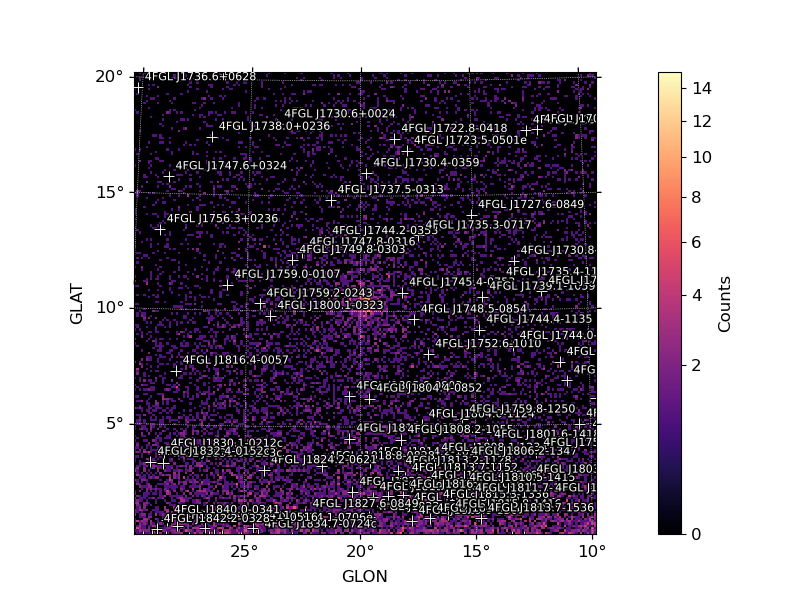

In [39]:
from IPython.display import Image
Image(filename='RS_Oph_fit_counts_map_2.000_5.699.png') 

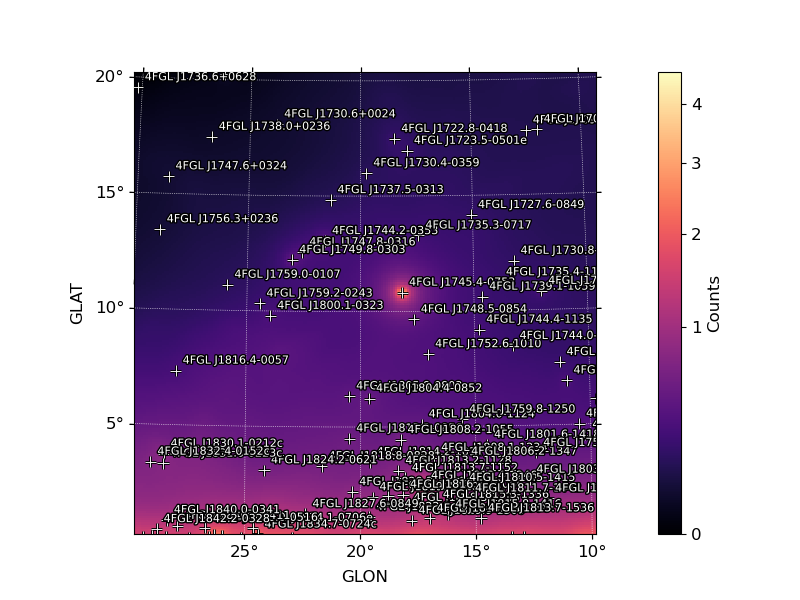

In [40]:
Image(filename='RS_Oph_fit_model_map_2.000_5.699.png') 

For a better visualization, let's check the projection on latitude

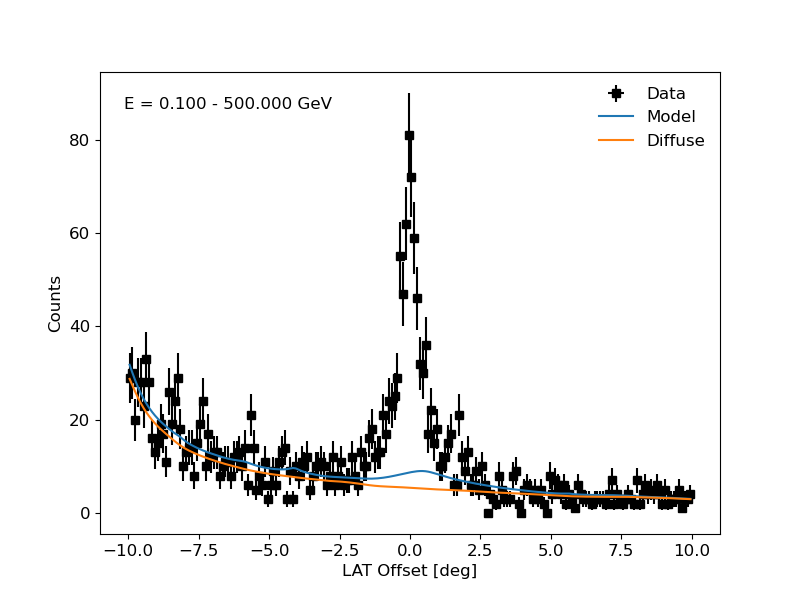

In [41]:
Image(filename='RS_Oph_fit_counts_map_yproj_2.000_5.699.png') 

We can see in these plots that the model does not fit well the data. Let's continue our evaluation of the ROI with the production of the TS map

2026-07-02 15:44:33 INFO    GTAnalysis.tsmap(): Generating TS map
2026-07-02 15:44:44 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2026-07-02 15:45:49 INFO    GTAnalysis.tsmap(): Finished TS map
2026-07-02 15:46:05 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /home/willde/Documents/Teaching/ICE_school/TSmap_fit_pointsource_powerlaw_2.00_tsmap.npy
2026-07-02 15:46:05 INFO    GTAnalysis.tsmap(): Execution time: 92.17 s


<Figure size 800x600 with 0 Axes>

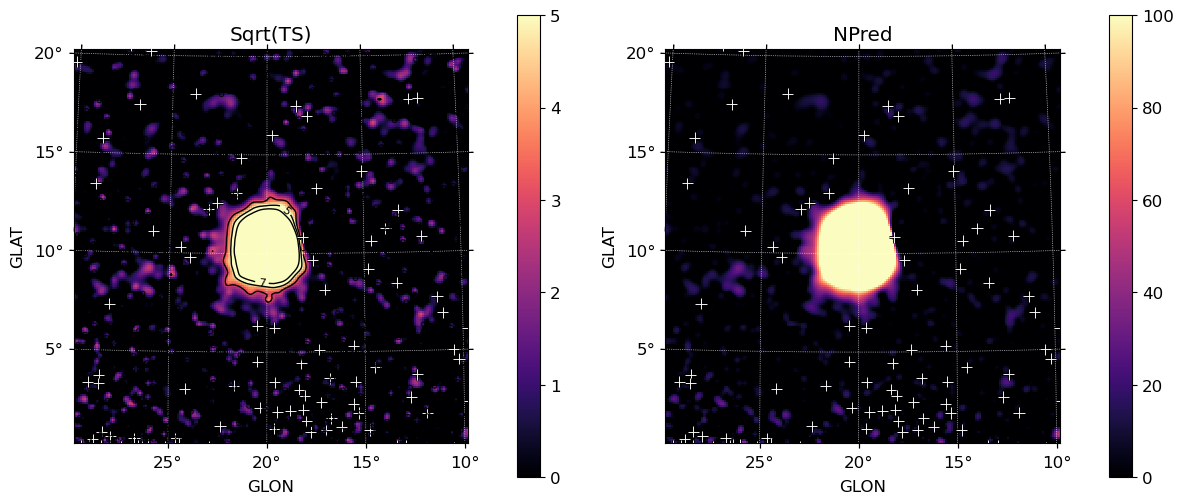

In [24]:
tsmap = gta.tsmap(prefix='TSmap_fit',model={'SpatialModel' : 'PointSource', 'Index': 2.0}, make_plots=True,write_fits=True,write_npy=True)

plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', label_ts_threshold=1e9)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma', label_ts_threshold=1e9)
plt.gca().set_title('NPred')
plt.show()

# label_ts_threshold=1e9 is only set to remove the names of all sources


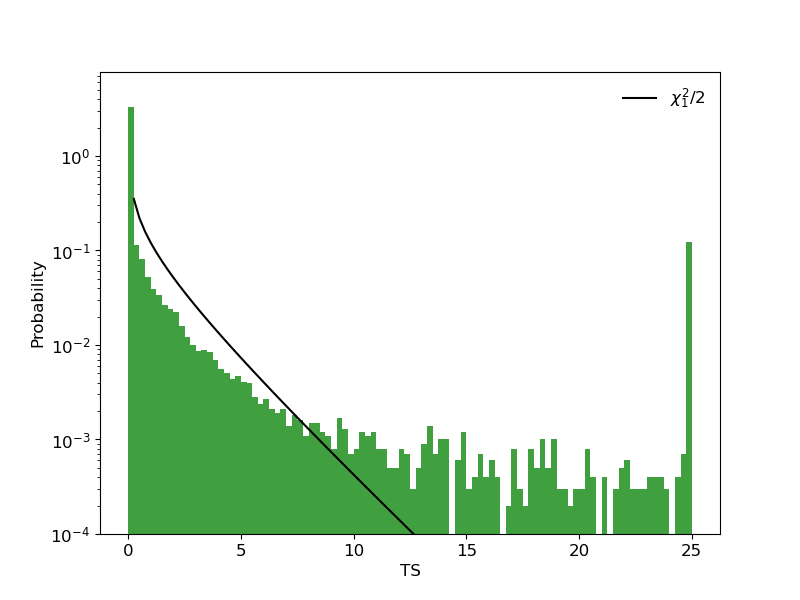

In [25]:
Image(filename='TSmap_fit_pointsource_powerlaw_2.00_tsmap_ts_hist.png') 

The TS map is by default positive, let's see a residual estimate.

*Disclaimer*: Fermipy's residual estimator is not exact, specially for large variations. It is advisable to also check the PS map ([fermipy dscription](https://fermipy.readthedocs.io/en/latest/advanced/psmap.html), [Bruel 2021](https://arxiv.org/pdf/2109.07443)).

2026-07-02 15:46:07 INFO    GTAnalysis.residmap(): Generating residual maps
2026-07-02 15:46:07 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2026-07-02 15:46:12 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2026-07-02 15:46:21 INFO    GTAnalysis.residmap(): Finished residual maps
2026-07-02 15:46:36 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /home/willde/Documents/Teaching/ICE_school/Residmap_fit_pointsource_powerlaw_2.00_residmap.npy
2026-07-02 15:46:36 INFO    GTAnalysis.residmap(): Execution time: 28.46 s


<Figure size 640x480 with 0 Axes>

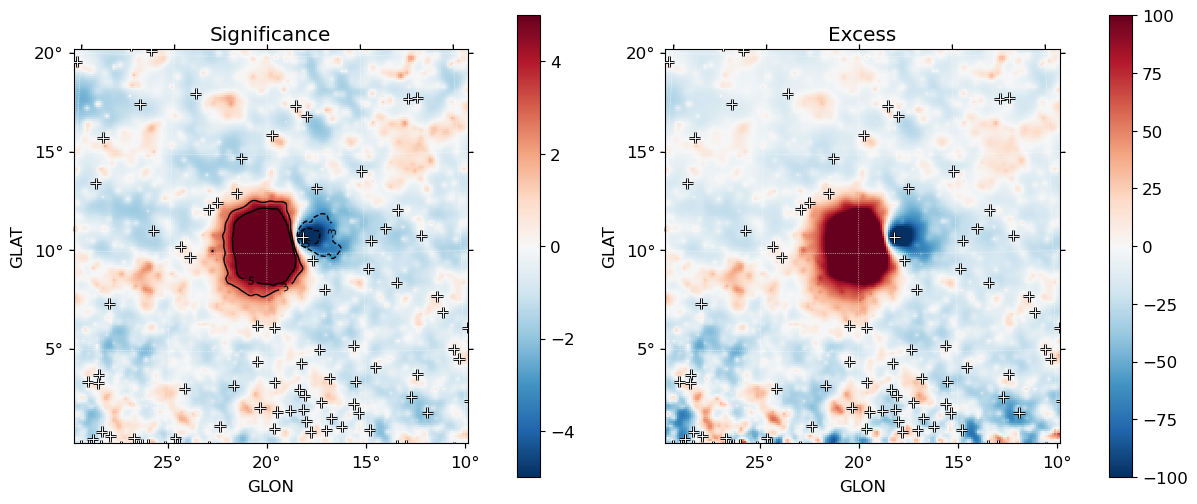

In [26]:
resid = gta.residmap('Residmap_fit',model={'SpatialModel' : 'PointSource', 'Index' : 2.0},write_fits=True,write_npy=True,make_plots=True)

plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid['sigma'],roi=gta.roi).plot(vmin=-5,vmax=5,levels=[-5,-3,3,5],subplot=121,cmap='RdBu_r', label_ts_threshold=1e9)
plt.gca().set_title('Significance')
ROIPlotter(resid['excess'],roi=gta.roi).plot(vmin=-100,vmax=100,subplot=122,cmap='RdBu_r', label_ts_threshold=1e9)
plt.gca().set_title('Excess')
plt.show()

As you can see, the fit was succesful, **but the solution you found does not represent the data**. Always check the ROI!

Since clearly there is room for improvement, what could we do?

- Remove unnecessary degrees of freedom
- Add a source to account for the emission of the nova RS Oph

Adding a source is relatively simple. Here we will use a LogParabola, as we know that the spectrum si curve. Normally, you should start with a PowerLaw (there is no 'beta' parameter), and then see if it reproduces well the data. For all spectral models, see [here](https://fermi.gsfc.nasa.gov/ssc/data/analysis/scitools/source_models.html).

Note that you can add your own spatial and/or spectral models as files!

In [27]:
# Delete
gta.delete_sources(minmax_ts=[None, 4])
gta.delete_sources(minmax_npred=[None, 1])

# Add
gta.add_source('RS_Oph',{'ra' : 267.555, 'dec':-6.70791, 'SpectrumType' : 'LogParabola', 
                          'Index':2, 'beta' : 1, 'Scale' : 1000, 'Prefactor': 1e-10, 'SpatialModel':'PointSource'})


# In this case we knew the position of the source, you could search for them using the function gta.find_sources()
# see -> https://fermipy.readthedocs.io/en/latest/advanced/detection.html#findsources


2026-07-02 15:46:37 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1748.5-0854
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1747.8-0316
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1752.6-1010
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1735.3-0717
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1805.8-0803
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1800.1-0323
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1804.4-0852
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1759.2-0243
2026-07-02 15:46:38 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1737.5-0313
2026-07-02 15:46:39 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1744.4-1135
2026-07-02 15:46:39 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1739.1-1059
2026-07-02

Now that we have improved the source list, let's fit again!

In [28]:
gta.free_sources(free=False)
gta.free_sources(distance=10, pars='norm')
gta.free_sources(minmax_ts=[10,None])
gta.free_source('RS_Oph')

gta.fit()

# First freeze all
gta.free_sources(free=False)

gta.write_roi('RS_Oph_with_new_src', make_plots=True)

2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Fixing parameters for RS_Oph                : ['norm']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for RS_Oph                : ['norm']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1745.4-0753     : ['Prefactor']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1744.2-0353     : ['Prefactor']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1749.8-0303     : ['norm']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1733.0-1305     : ['norm']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1813.4-1246     : ['Prefactor']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2026-07-02 15:46:54 INFO    GTAnalysis.free_source(): Freeing parameters for galdiff             

2026-07-02 15:47:29 INFO    GTAnalysis.tsmap(): Generating TS map
2026-07-02 15:47:34 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2026-07-02 15:48:41 INFO    GTAnalysis.tsmap(): Finished TS map
2026-07-02 15:48:59 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /home/willde/Documents/Teaching/ICE_school/TSmap_fit_with_RS_Oph_pointsource_powerlaw_2.00_tsmap.npy
2026-07-02 15:48:59 INFO    GTAnalysis.tsmap(): Execution time: 89.96 s


<Figure size 800x600 with 0 Axes>

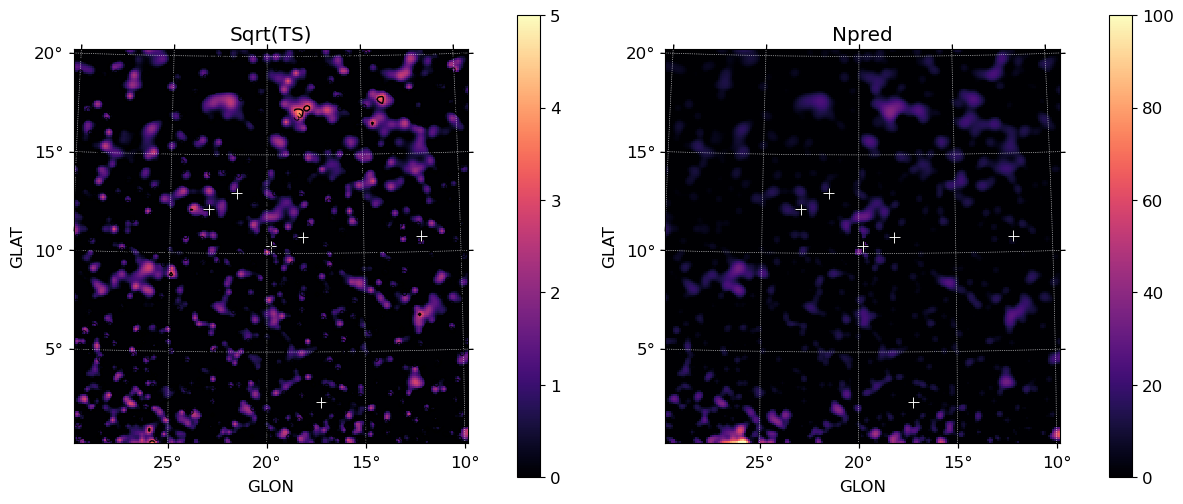

In [29]:
tsmap_new = gta.tsmap(prefix='TSmap_fit_with_RS_Oph',model={'SpatialModel' : 'PointSource', 'Index': 2.0}, make_plots=True,write_fits=True,write_npy=True)

plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_new['sqrt_ts'],roi=gta.roi).plot(levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', label_ts_threshold=1e9)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_new['npred'],roi=gta.roi).plot(vmin=0,vmax=100,subplot=122,cmap='magma', label_ts_threshold=1e9)
plt.gca().set_title('Npred')
plt.show()

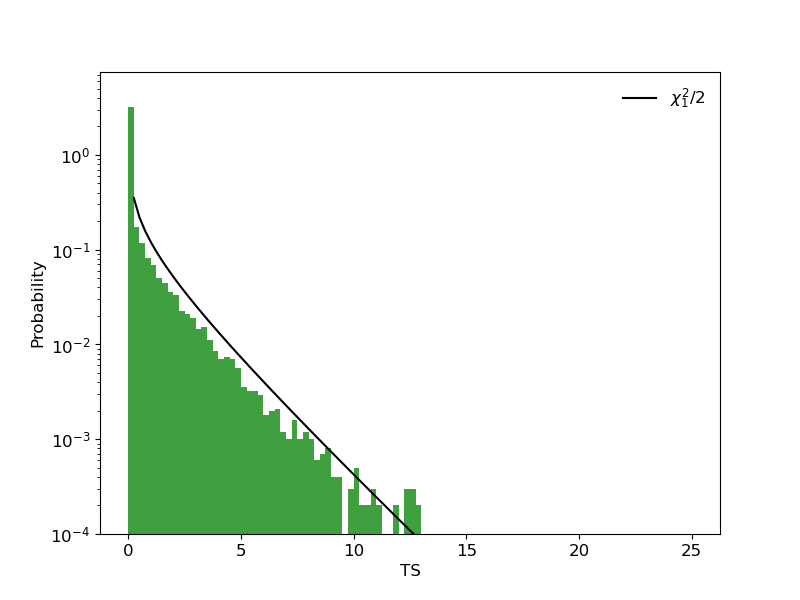

In [30]:
Image(filename='TSmap_fit_with_RS_Oph_pointsource_powerlaw_2.00_tsmap_ts_hist.png') 

2026-07-02 15:49:00 INFO    GTAnalysis.residmap(): Generating residual maps
2026-07-02 15:49:00 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2026-07-02 15:49:08 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2026-07-02 15:49:13 INFO    GTAnalysis.residmap(): Finished residual maps
2026-07-02 15:49:29 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /home/willde/Documents/Teaching/ICE_school/Residmap_fit_new_pointsource_powerlaw_2.00_residmap.npy
2026-07-02 15:49:29 INFO    GTAnalysis.residmap(): Execution time: 28.72 s


<Figure size 640x480 with 0 Axes>

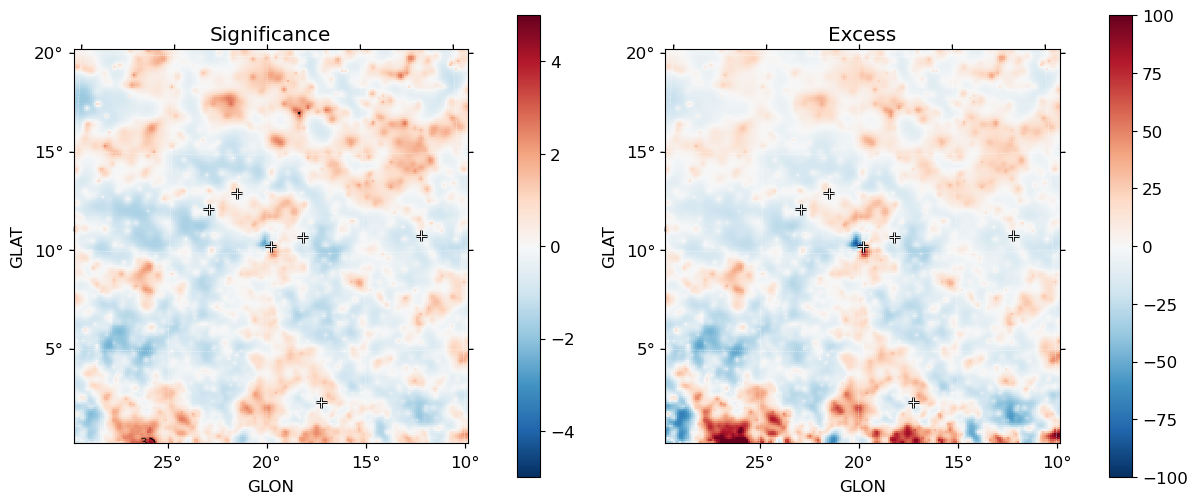

In [31]:
resid_new = gta.residmap('Residmap_fit_new',model={'SpatialModel' : 'PointSource', 'Index' : 2.0},write_fits=True,write_npy=True,make_plots=True)

plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid_new['sigma'],roi=gta.roi).plot(vmin=-5,vmax=5,levels=[-5,-3,3,5],subplot=121,cmap='RdBu_r', label_ts_threshold=1e9)
plt.gca().set_title('Significance')
ROIPlotter(resid_new['excess'],roi=gta.roi).plot(vmin=-100,vmax=100,subplot=122,cmap='RdBu_r', label_ts_threshold=1e9)
plt.gca().set_title('Excess')
plt.show()

And let's see the properties of the source, and the ROI

In [32]:
print(gta.roi['RS_Oph'])

Name           : RS_Oph
Associations   : ['RS_Oph']
RA/DEC         :    267.555/    -6.708
GLON/GLAT      :     19.799/    10.372
TS             : 2580.34
Npred          : 1229.83
Flux           : 1.975e-06 +/- 1.06e-07
EnergyFlux     :  0.001177 +/- 6.96e-05
SpatialModel   : PointSource
SpectrumType   : LogParabola
Spectral Parameters
b'norm'        :  3.049e-10 +/-  1.531e-11
b'alpha'       :      1.992 +/-    0.04013
b'beta'        :     0.1773 +/-    0.02804
b'Eb'          :       1000 +/-        nan


In [33]:
gta.print_roi()

2026-07-02 15:49:31 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
RS_Oph              PointSource    LogParabola       0.000   2580.34      1229.8
4FGL J1745.4-0753   PointSource    PowerLaw          1.671      1.83        10.6
4FGL J1744.2-0353   PointSource    PowerLaw          3.191      4.48        24.0
4FGL J1749.8-0303   PointSource    LogParabola       3.657      5.46        37.7
4FGL J1733.0-1305   PointSource    LogParabola       7.651      7.12        24.7
4FGL J1813.4-1246   PointSource    PLSuperExpCuto    8.326     83.50       266.0
isodiff             ConstantValue  FileFunction      -----      1.65       193.3
galdiff             MapCubeFunctio PowerLaw          -----  30367.98     14218.0



### **Advanced functions**

**Localization**

In [34]:
loc = gta.localize('RS_Oph',make_plots=True)

2026-07-02 15:49:31 INFO    GTAnalysis.localize(): Running localization for RS_Oph
2026-07-02 15:49:52 INFO    GTAnalysis._localize(): Localization succeeded.
2026-07-02 15:49:52 INFO    GTAnalysis._localize(): Updating source RS_Oph to localized position.
2026-07-02 15:49:52 INFO    GTAnalysis.delete_source(): Deleting source RS_Oph
2026-07-02 15:49:52 INFO    GTAnalysis.add_source(): Adding source RS_Oph
2026-07-02 15:49:57 INFO    GTAnalysis._localize(): Localization completed with new position:
(  ra, dec) = (  267.5506 +/-   0.0124,   -6.7404 +/-   0.0119)
(glon,glat) = (   19.7685 +/-   0.0119,   10.3601 +/-   0.0124)
offset =   0.0328 r68 =   0.0184 r95 =   0.0297 r99 =   0.0369
2026-07-02 15:49:57 INFO    GTAnalysis._localize(): LogLike:   -65085.272 DeltaLogLike:        3.843
2026-07-02 15:49:57 INFO    GTAnalysis.localize(): Finished localization.
2026-07-02 15:50:10 WARNING GTAnalysis.localize(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, r

*Disclaimer/Question*: Have you seen the DeltaLogLike? How many degrees of freedom do we have? Is this change significant?

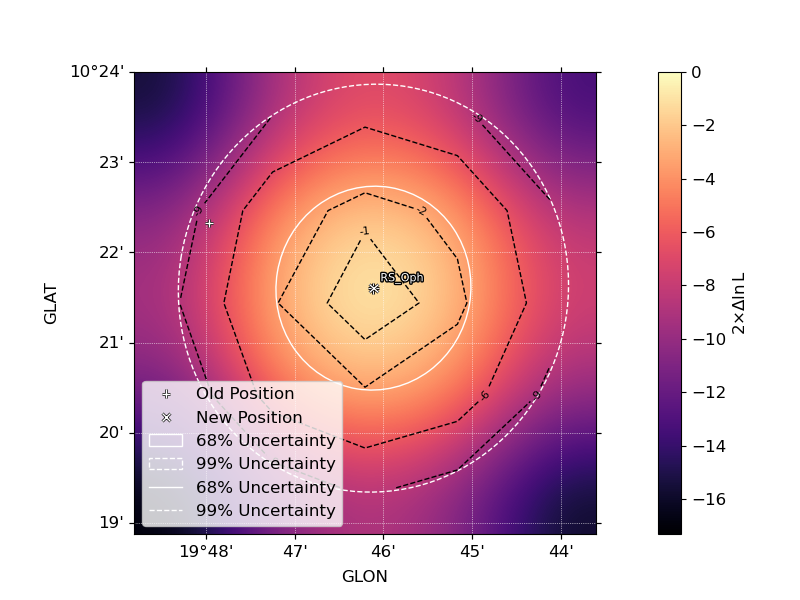

In [35]:
Image(filename='rs_oph_localize_peak.png') 

*Disclaimer* : The bin size we set is 0.1° ! The automatic localization plot is smoothed, but you can plot as you prefer it using the generated files

**Spectral energy distribution**

In [36]:
sed = gta.sed('RS_Oph',make_plots=True, loge_bins=[2,2.25,2.5,2.75,3.0,3.25,3.5,3.75,4.0,4.5,5,5.5])

2026-07-02 15:50:10 INFO    GTAnalysis.sed(): Computing SED for RS_Oph
2026-07-02 15:50:10 INFO    GTAnalysis._make_sed(): Fitting SED
2026-07-02 15:50:10 INFO    GTAnalysis.free_source(): Freeing parameters for RS_Oph                : ['norm']
2026-07-02 15:50:11 INFO    GTAnalysis.sed(): Finished SED
2026-07-02 15:50:27 INFO    GTAnalysis.sed(): Execution time: 16.85 s


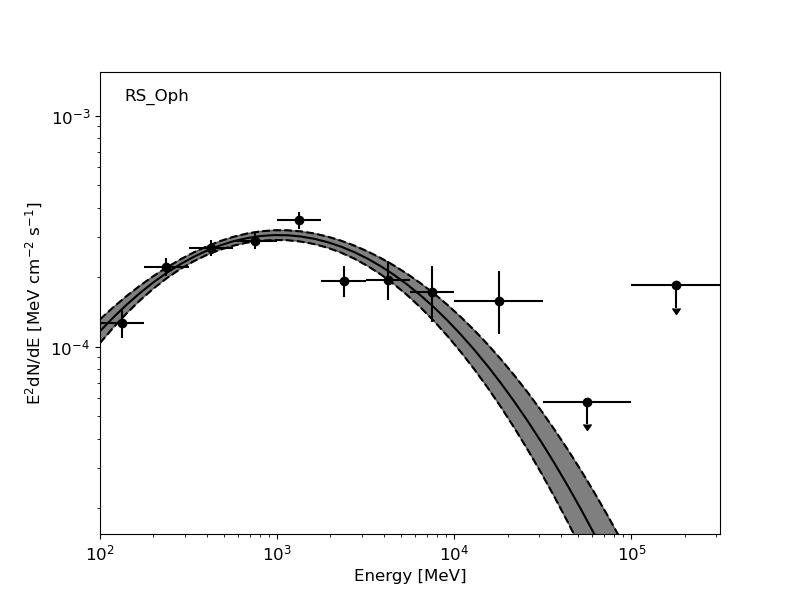

In [37]:
Image(filename='rs_oph_sed.png') 

**Light curve**

In [ ]:
lc = gta.lightcurve("RS_Oph", binsz=86400, free_radius=3) # alternatively, you could set the number of bins with nbins

2026-07-02 16:09:50 INFO    GTAnalysis.lightcurve(): Computing Lightcurve for RS_Oph
2026-07-02 16:09:53 INFO    lightcurve_650073605_650160005 GTAnalysis._process_lc_bin(): Fitting time range 650073605 650160005
2026-07-02 16:09:54 INFO    lightcurve_650073605_650160005 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
2026-07-02 16:15:00 INFO    lightcurve_650073605_650160005 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650073605_650160005/base_00.xml...


Joint fit  ['RS_Oph']
Fitting shape RS_Oph TS:     29.138


2026-07-02 16:15:01 INFO    lightcurve_650073605_650160005 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650073605_650160005/fit_model_final_00.xml...
2026-07-02 16:15:01 INFO    lightcurve_650073605_650160005 GTAnalysis._process_lc_bin(): Finished time range 650073605 650160005
2026-07-02 16:15:04 INFO    lightcurve_650160005_650246405 GTAnalysis._process_lc_bin(): Fitting time range 650160005 650246405
2026-07-02 16:15:05 INFO    lightcurve_650160005_650246405 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
2026-07-02 16:20:25 INFO    lightcurve_650160005_650246405 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650160005_650246405/base_00.xml...


Joint fit  ['RS_Oph']
Fitting shape RS_Oph TS:    827.132


2026-07-02 16:20:25 INFO    lightcurve_650160005_650246405 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650160005_650246405/fit_model_final_00.xml...
2026-07-02 16:20:26 INFO    lightcurve_650160005_650246405 GTAnalysis._process_lc_bin(): Finished time range 650160005 650246405
2026-07-02 16:20:29 INFO    lightcurve_650246405_650332805 GTAnalysis._process_lc_bin(): Fitting time range 650246405 650332805
2026-07-02 16:20:30 INFO    lightcurve_650246405_650332805 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
2026-07-02 16:25:53 INFO    lightcurve_650246405_650332805 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650246405_650332805/base_00.xml...


...

2026-07-02 16:37:03 INFO    lightcurve_650419205_650505605 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650419205_650505605/fit_model_final_00.xml...
2026-07-02 16:37:03 INFO    lightcurve_650419205_650505605 GTAnalysis._process_lc_bin(): Finished time range 650419205 650505605
2026-07-02 16:37:08 INFO    lightcurve_650505605_650592005 GTAnalysis._process_lc_bin(): Fitting time range 650505605 650592005
2026-07-02 16:37:08 INFO    lightcurve_650505605_650592005 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
2026-07-02 16:42:43 INFO    lightcurve_650505605_650592005 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650505605_650592005/base_00.xml...


Joint fit  ['RS_Oph']
Fitting shape RS_Oph TS:    224.905


2026-07-02 16:42:43 INFO    lightcurve_650505605_650592005 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650505605_650592005/fit_model_final_00.xml...
2026-07-02 16:42:44 INFO    lightcurve_650505605_650592005 GTAnalysis._process_lc_bin(): Finished time range 650505605 650592005
2026-07-02 16:42:48 INFO    lightcurve_650592005_650678405 GTAnalysis._process_lc_bin(): Fitting time range 650592005 650678405
2026-07-02 16:42:48 INFO    lightcurve_650592005_650678405 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.
2026-07-02 16:48:06 INFO    lightcurve_650592005_650678405 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650592005_650678405/base_00.xml...


Joint fit  ['RS_Oph']
Fitting shape RS_Oph TS:     84.550


2026-07-02 16:48:06 INFO    lightcurve_650592005_650678405 GTBinnedAnalysis.write_xml(): Writing /home/willde/Documents/Teaching/ICE_school/lightcurve_650592005_650678405/fit_model_final_00.xml...
2026-07-02 16:48:07 INFO    lightcurve_650592005_650678405 GTAnalysis._process_lc_bin(): Finished time range 650592005 650678405
2026-07-02 16:48:11 INFO    lightcurve_650678405_650764805 GTAnalysis._process_lc_bin(): Fitting time range 650678405 650764805
2026-07-02 16:48:11 INFO    lightcurve_650678405_650764805 GTBinnedAnalysis._create_ltcube(): Generating local LT cube.


In [ ]:
# Did it work?
print(lc['fit_success'])

In [ ]:
plt.clf()
fig = plt.figure(figsize=(8,6))
plt.errorbar((lc['tmin']+lc['tmax'])/2., lc['flux'], yerr=lc['flux_err'], xerr=(lc['tmax']-lc['tmin'])/2., fmt="o", color="black")
plt.ylabel(r'$\Phi_{\gamma}$ [ph/cm$^2$/s]', fontsize=18)
plt.xlabel(r'$t$ [s]')
plt.axis([lc['tmin'][0],lc['tmax'][-1],5e-8,1e-5])
plt.grid(True)
plt.yscale('log')
plt.xscale('linear')
fig.tight_layout(pad=0.5)
plt.show()